# Jump diffusion

A jump-diffusion process is a smooth diffusion (like GBM) punctuated by sudden *jumps* — the model for prices that mostly drift but occasionally gap on news. It is a realistic test for methods that must distinguish ordinary volatility from discrete shocks.

::: {.callout-note}
## The model

$$dS_t = \mu S_t\, dt + \sigma S_t\, dW_t + S_{t^-}\, dJ_t, \qquad N_t \sim \mathrm{Poisson}(\lambda\, dt)$$

A continuous diffusion accumulates small changes while a Poisson jump process adds occasional discrete moves. The jump intensity sets how often jumps occur; the jump-size distribution sets how large they are. Between jumps the series behaves like its underlying diffusion.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import JumpDiffusionGenerator

## 1. Jump intensity

`lambda_jump` is the expected number of jumps per unit time. Between jumps the path is an ordinary diffusion, so raising it adds discontinuities without changing the underlying drift.


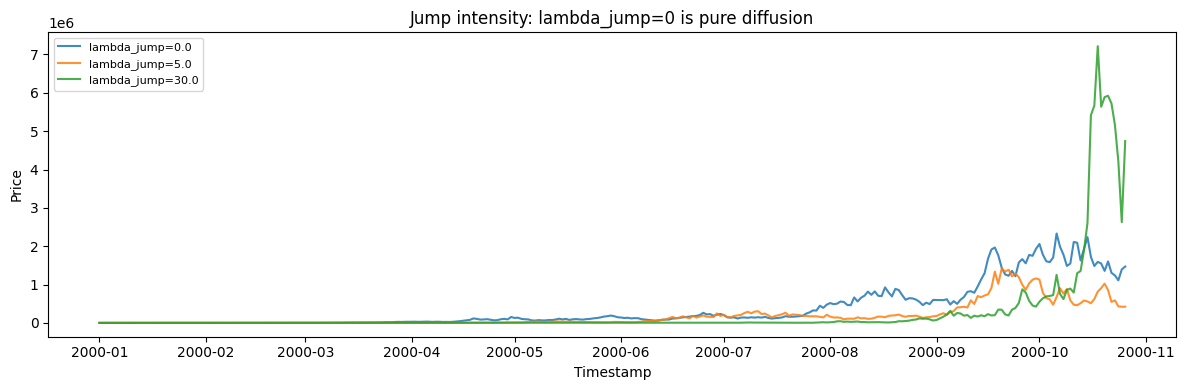

In [ ]:
base = {
    "min_length": 300,
    "max_length": 300,
    "freq": "D",
    "mu": 0.05,
    "sigma": 0.15,
    "jump_mean": 0.0,
    "jump_std": 0.05,
    "initial_value": 100.0,
    "seed": 42,
}

fig, ax = plt.subplots(figsize=(12, 4))
for lambda_jump in (0.0, 5.0, 30.0):
    df = JumpDiffusionGenerator(
        engine="polars", lambda_jump=lambda_jump, **base
    ).generate(n_series=1)
    ax.plot(
        df["ds"].to_list(), df["y"].to_list(), label=f"lambda_jump={lambda_jump}", alpha=0.85
    )
ax.set(
    xlabel="Timestamp",
    ylabel="Price",
    title="Jump intensity: lambda_jump=0 is pure diffusion",
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 2. Jump direction

`jump_mean` is the average log jump size, so its sign decides whether shocks push the price up or down. The drift is not compensated for jumps, which is why a negative mean drags the whole path down.


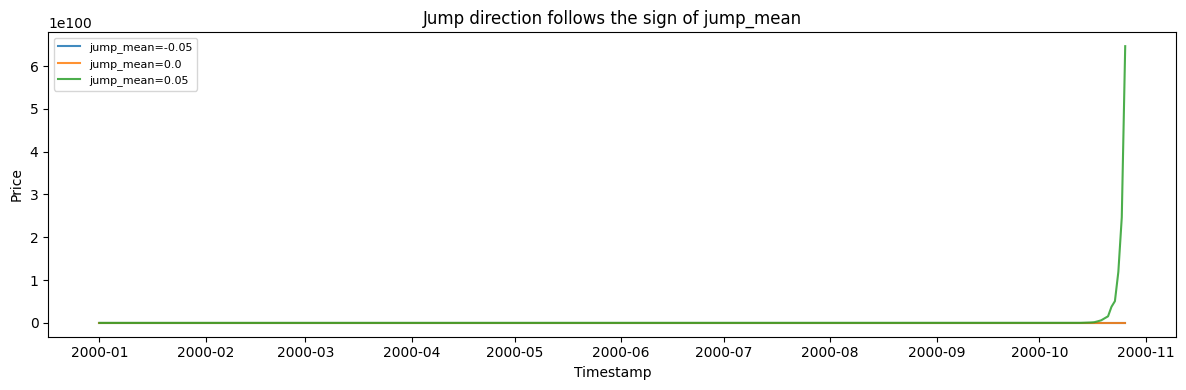

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for jump_mean in (-0.05, 0.0, 0.05):
    df = JumpDiffusionGenerator(
        engine="polars",
        min_length=300,
        max_length=300,
        freq="D",
        mu=0.05,
        sigma=0.15,
        lambda_jump=15.0,
        jump_mean=jump_mean,
        jump_std=0.02,
        initial_value=100.0,
        seed=42,
    ).generate(n_series=1)
    ax.plot(
        df["ds"].to_list(), df["y"].to_list(), label=f"jump_mean={jump_mean}", alpha=0.85
    )
ax.set(xlabel="Timestamp", ylabel="Price", title="Jump direction follows the sign of jump_mean")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3. Multiple series

Generate multiple independent jump diffusion paths.

In [ ]:
multi_params = {
    "min_length": 150,
    "max_length": 150,
    "freq": "D",
    "mu": 0.05,
    "sigma": 0.15,
    "lambda_jump": 0.2,
    "jump_mean": 0.0,
    "jump_std": 0.1,
    "initial_value": 100.0,
    "seed": 42,
}

multi_gen = JumpDiffusionGenerator(engine="polars", **multi_params)
multi_df = multi_gen.generate(n_series=3)

print(f"Generated 3 series with {len(multi_df)} total observations")
print(f"Overall Statistics: Mean={multi_df['y'].mean():.4f}, Std={multi_df['y'].std():.4f}")
multi_df.filter(pl.col("unique_id") == "0").head(10)

Generated 3 series with 450 total observations
Overall Statistics: Mean=6662.1054, Std=16489.8470


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.0
"""0""",2000-01-02 00:00:00,84.240947
"""0""",2000-01-03 00:00:00,94.557346
"""0""",2000-01-04 00:00:00,107.575297
"""0""",2000-01-05 00:00:00,114.688591
"""0""",2000-01-06 00:00:00,159.7268
"""0""",2000-01-07 00:00:00,146.174789
"""0""",2000-01-08 00:00:00,171.596255
"""0""",2000-01-09 00:00:00,174.553944


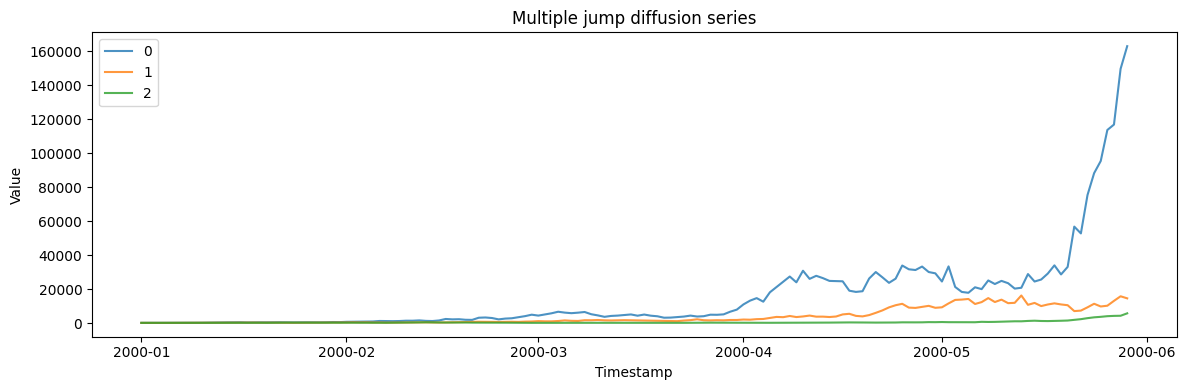

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple jump diffusion series")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Geometric Brownian motion](/synforecast/docs/generators/stochastic/geometric_brownian_motion.html) — the jump-free diffusion.
- [Hawkes process](/synforecast/docs/generators/stochastic/hawkes_process.html) — when the jumps cluster and self-excite.

Jump intensity and size parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::